<a href="https://colab.research.google.com/github/monasolgi/Computer_vision/blob/main/tutorial5_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

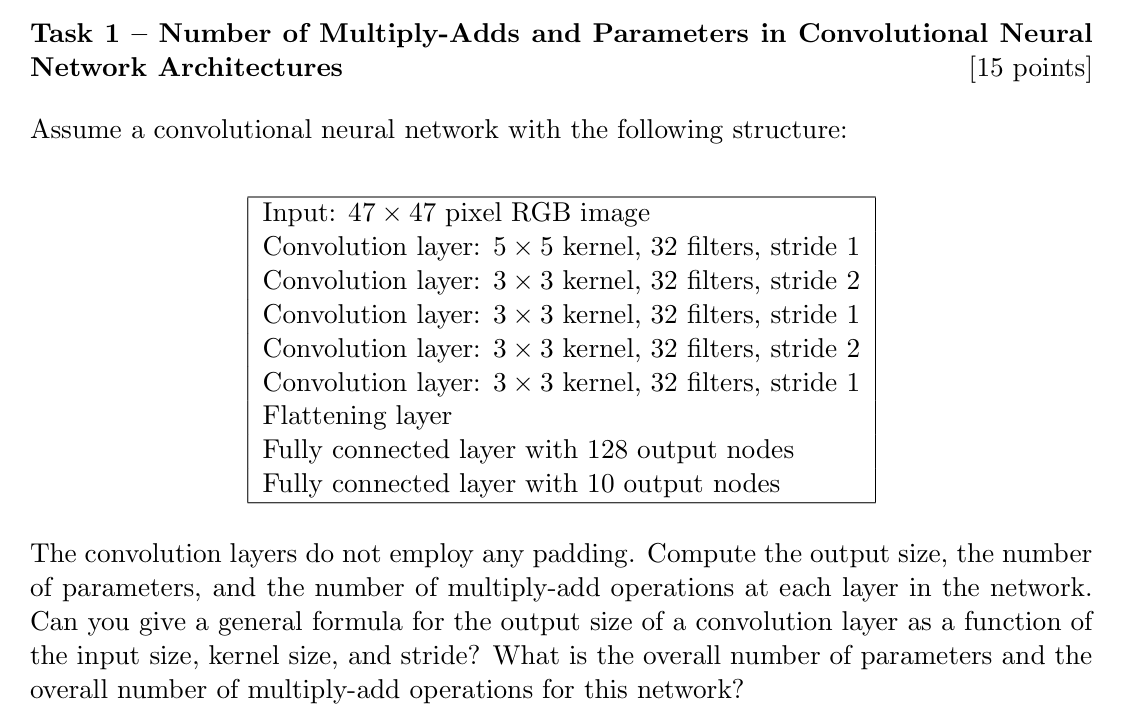

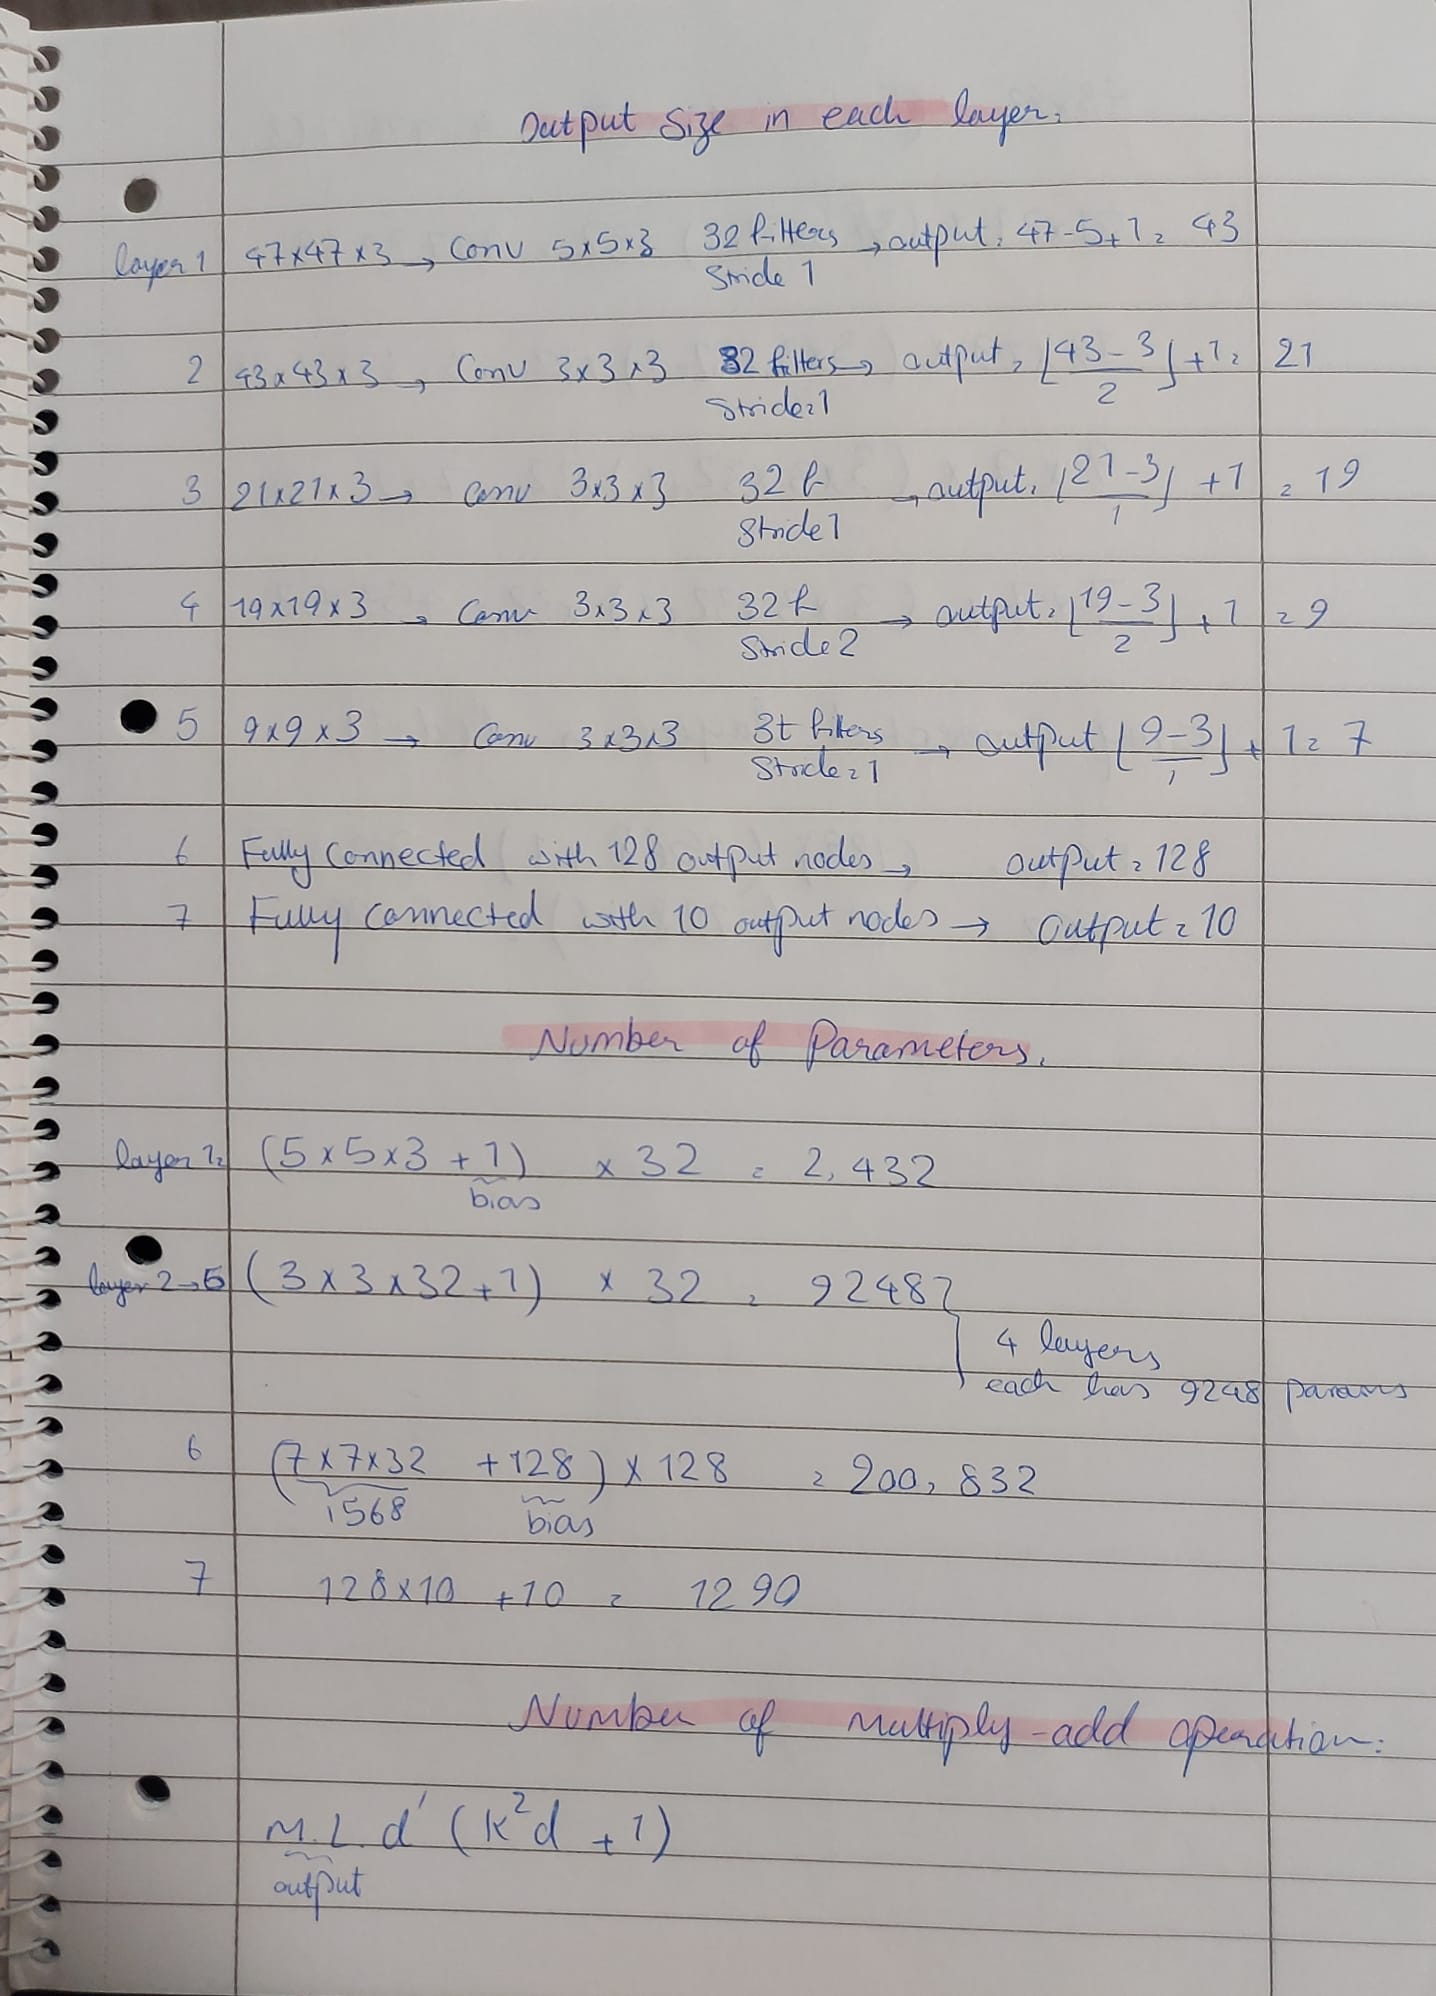

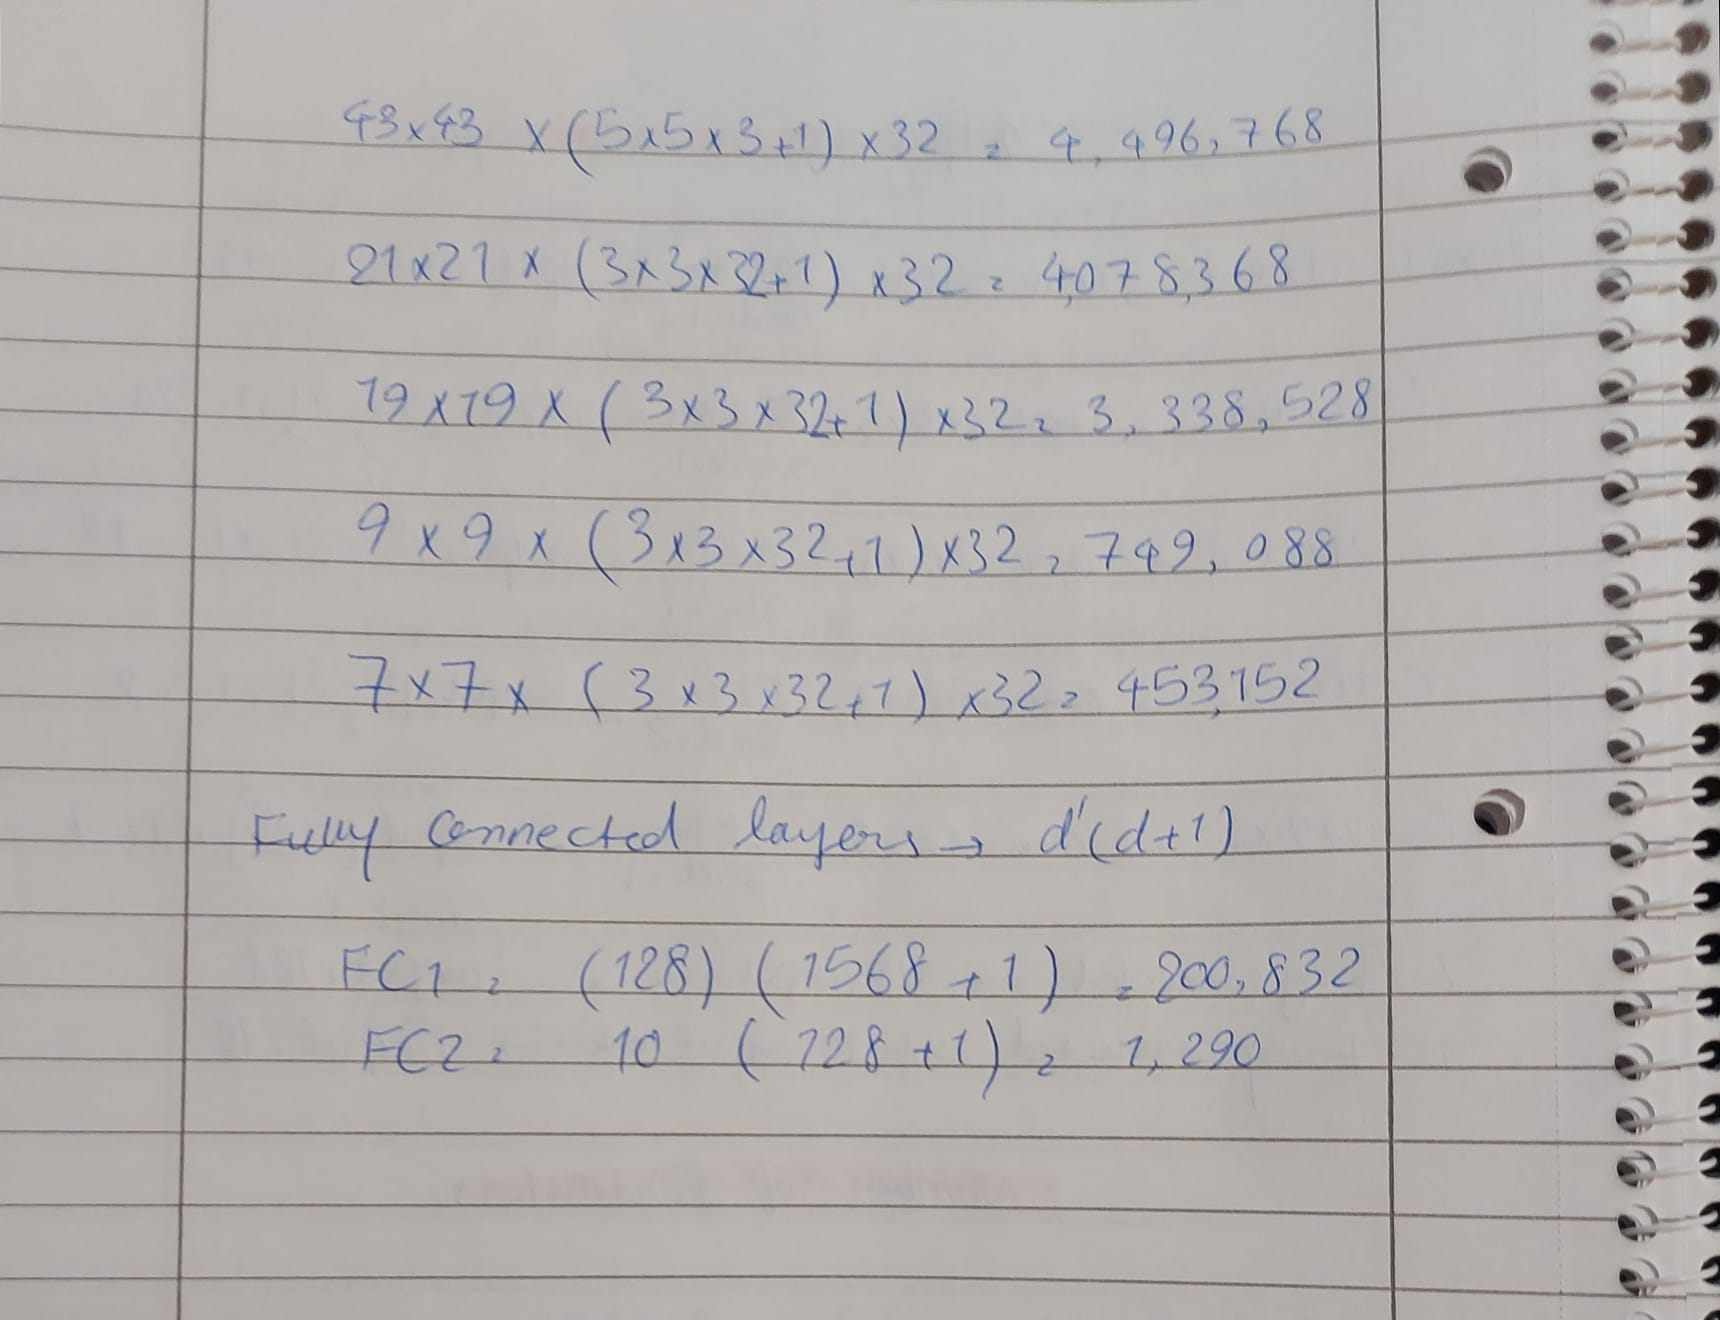

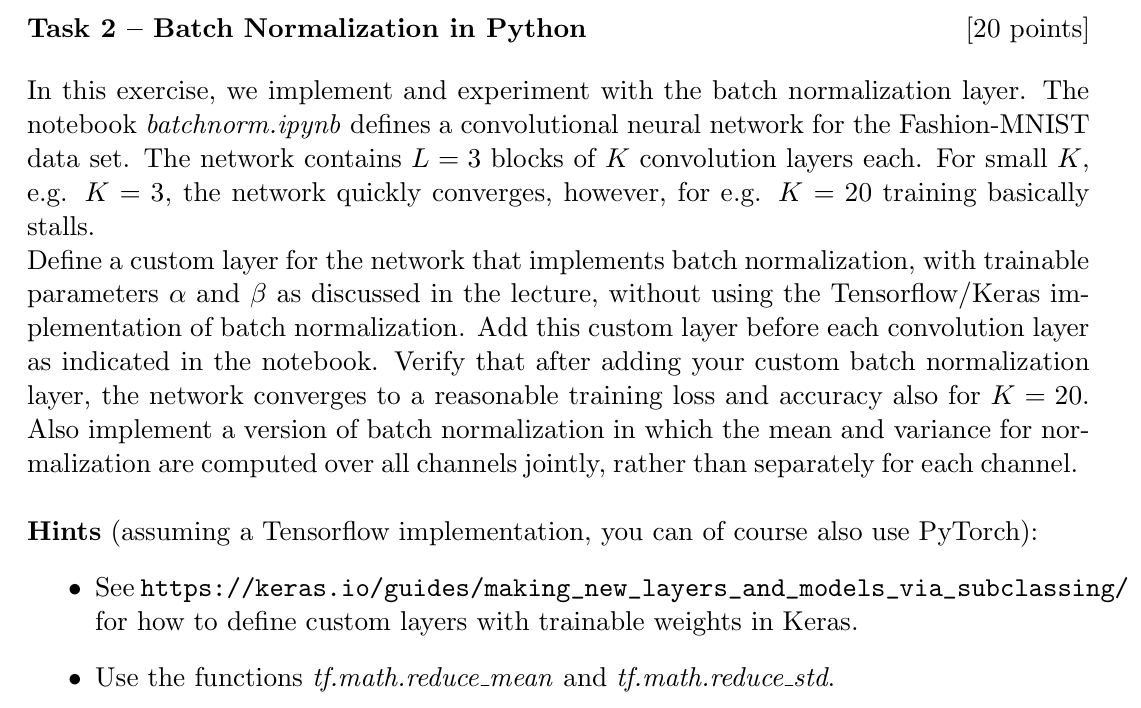

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import keras
from keras import ops

import sys
import numpy as np
import matplotlib.pyplot as plt


class MyBatchNormalization(keras.layers.Layer):
    def __init__(self,global_normalization=False):
        super().__init__()
        self.epsilon = 1e-5
        self.global_normalization=global_normalization

    def build(self, input_tensor):
      self.alpha = self.add_weight(
            shape=(input_tensor[-1],),
            initializer="ones",
            trainable=True,
        )
      self.beta = self.add_weight(shape=(input_tensor[-1],),
                                 initializer="zeros", trainable=True)

    def call(self,input_tensor):
      if self.global_normalization:
        axes=[0,1,2,3]
      else:
        axes=[0,1,2]
      mean=tf.math.reduce_mean(
          input_tensor,
          axis=axes,
          keepdims=True,
          name=None
          )
      std=tf.math.reduce_std(
          input_tensor,
          axis=axes,
          keepdims=True,
          name=None
          )
      input_tensor = (input_tensor - mean) / (std+self.epsilon)
      return input_tensor* self.alpha + self.beta

def define_model():
    inputs = keras.Input(shape=(28,28,1))

    K = 20 # number of convolution layers per block
    L = 3  # number of blocks
    x = inputs
    for i in range(0,L):
        for j in range(0,K):
            # Add call to custom layer here: x = MyBatchNormalization()(x)
            x = layers.Conv2D(32, 3, activation="relu",padding="same")(x)
            x = MyBatchNormalization(global_normalization=True)(x)

        x = layers.MaxPooling2D(3)(x)
    x = layers.GlobalMaxPooling2D()(x)
    outputs = layers.Dense(10,activation='softmax')(x)

    model = keras.Model(inputs,outputs)
    model.summary() # show model overview
    return model


In [ ]:
# Load and preprocess training data (Fashion-MNIST)
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()
print(train_images.shape,test_images.shape)
#train_images = np.expand_dims(train_images, -1) #handeled implicitly by keras
#test_images = np.expand_dims(test_images, -1)
train_images = train_images / 255.0
test_images = test_images / 255.0
train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

# Define and train model
model = define_model()
model.compile(loss=keras.losses.CategoricalCrossentropy(),optimizer=keras.optimizers.Adam(),metrics=["accuracy"])
model.fit(train_images,train_labels, batch_size=64, epochs=100)

# Evaluate model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test accuracy:", test_acc)


(60000, 28, 28) (10000, 28, 28)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_batch_normalization_18       │ (None, 28, 28, 32)     │            64 │
│ (MyBatchNormalization)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_batch_normalization_19       │ (None, 28, 28, 32)     │            64 │
│ (MyBatchNormalization)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_batch_normalization_20       │ (None, 28, 28, 32)     │            64 │
│ (MyBatchNormalization)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_batch_normalization_21       │ (None, 28, 28, 32)     │            64 │
│ (MyBatchNormalization)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_batch_normalization_22       │ (None, 28, 28, 32)     │            64 │
│ (MyBatchNormalization)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_batch_normalization_23       │ (None, 28, 28, 32)     │            64 │
│ (MyBatchNormalization)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_batch_normalization_24       │ (None, 28, 28, 32)     │            64 │
│ (MyBatchNormalization)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_batch_normalization_25       │ (None, 28, 28, 32)     │            64 │
│ (MyBatchNormalization)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_batch_normalization_26       │ (None, 28, 28, 32)     │            64 │
│ (MyBatchNormalization)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 550,122 (2.10 MB)

 Trainable params: 550,122 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 116s 64ms/step - accuracy: 0.4454 - loss: 1.3088
Epoch 2/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.6402 - loss: 0.8608
Epoch 3/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.7154 - loss: 0.7395
Epoch 4/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.7308 - loss: 0.6973
Epoch 5/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.7733 - loss: 0.6152
Epoch 6/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.8059 - loss: 0.5303
Epoch 7/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.8242 - loss: 0.4898
Epoch 8/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.8318 - loss: 0.4708
Epoch 9/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.8489 - loss: 0.4306
Epoch 10/100
718/938 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.8556 - loss: 0.4025

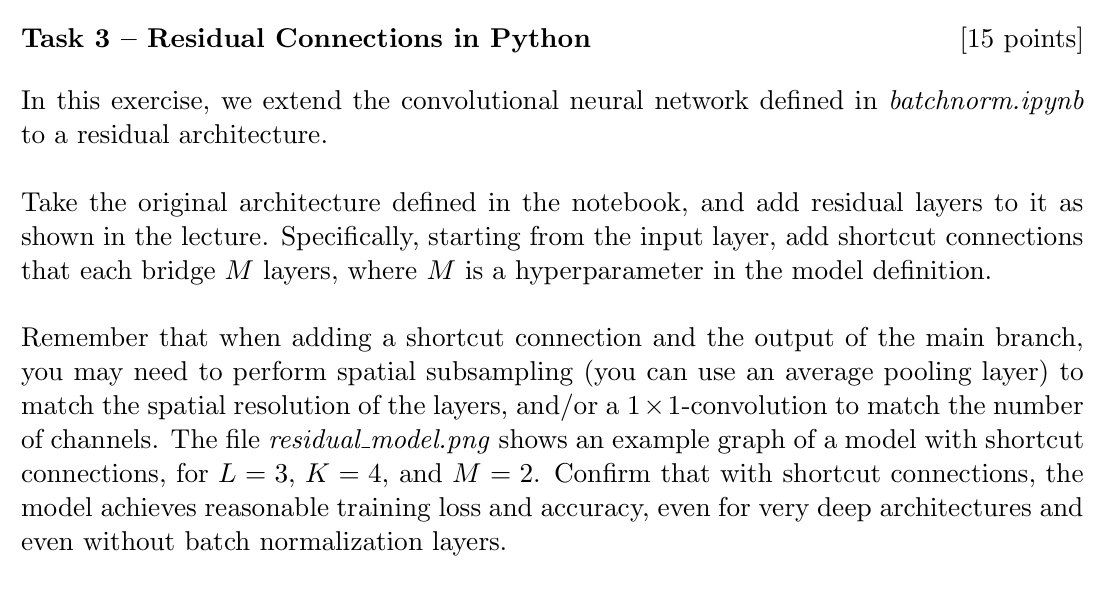

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt


def ResidualBlock(x, M, filters=32, downsample=False):
    # Create skip connection
    x_skip = x

    # Main branch
    for i in range(M):
        if i == 0 and downsample:
            stride = 2
        else:
            stride = 1

        x = layers.Conv2D(
            filters,
            kernel_size=3,
            activation="relu",
            padding="same",
            strides=stride
        )(x)

    # Match channel dimension if needed
    if x.shape[-1] != x_skip.shape[-1]:
        x_skip = layers.Conv2D(
            filters,
            kernel_size=1,
            padding="same"
        )(x_skip)

    # Match spatial dimension if needed
    if downsample:
        x_skip = layers.AveragePooling2D(pool_size=2)(x_skip)

    # Add shortcut connection
    x = layers.Add()([x, x_skip])

    return x


def define_model():
    inputs = keras.Input(shape=(28, 28, 1))
    x = inputs

    K = 4  # number of convolution layers per block
    L = 3  # number of big blocks
    M = 2  # number of conv layers per residual block

    filters = 32

    for i in range(L):
        if i > 0:
            filters *= 2

        for j in range(K // M):
            downsample = (i > 0 and j == 0)
            x = ResidualBlock(x, M, filters, downsample)

    x = layers.GlobalMaxPooling2D()(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    model.summary()
    return model


# Load and preprocess training data
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

print(train_images.shape, test_images.shape)

train_images = train_images / 255.0
test_images = test_images / 255.0

train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)


# Define and train model
model = define_model()

model.compile(
    loss=keras.losses.CategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)

model.fit(
    train_images,
    train_labels,
    batch_size=64,
    epochs=100
)

# Evaluate model
test_loss, test_acc = model.evaluate(test_images, test_labels)

print("Test accuracy:", test_acc)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28) (10000, 28, 28)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 28, 28,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │         64 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 28,    │          0 │ conv2d_1[0][0],   │
│                     │ 32)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │      9,248 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │      9,248 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 28, 28,    │          0 │ conv2d_4[0][0],   │
│                     │ 32)               │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │     18,496 │ add_1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 28, 28,    │      2,112 │ add_1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 14, 14,    │     36,928 │ conv2d_5[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 14, 14,    │          0 │ conv2d_7[0][0]    │
│ (AveragePooling2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 14, 14,    │          0 │ conv2d_6[0][0],   │
│                     │ 64)               │            │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 14, 14,    │     36,928 │ add_2[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 14, 14,    │     36,928 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 14, 14,    │          0 │ conv2d_9[0][0],   │
│                     │ 64)               │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 7, 7, 128) │     73,856 │ add_3[0][0]     

 Total params: 685,738 (2.62 MB)

 Trainable params: 685,738 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8467 - loss: 0.4242
Epoch 2/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9034 - loss: 0.2657
Epoch 3/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9225 - loss: 0.2137
Epoch 4/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9334 - loss: 0.1828
Epoch 5/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9439 - loss: 0.1551
Epoch 6/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9512 - loss: 0.1335
Epoch 7/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9592 - loss: 0.1120
Epoch 8/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9648 - loss: 0.0961
Epoch 9/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9715 - loss: 0.0768
Epoch 10/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9749 - loss: 0.0689
Epoch 11/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9768 - loss: 0.0645
Epoch 12/100
938/93